In [20]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Load dataset
df = pd.read_csv("funnel_events_sample.csv")

In [3]:
df.head()

,user_id,step,timestamp
0,U023,details_filled,2026-07-20 04:00:00
1,U173,visited_site,2026-07-20 03:41:00
2,U096,visited_site,2026-07-20 03:34:00
3,U005,signup_started,2026-07-20 04:23:00
4,U178,visited_site,2026-07-20 03:38:00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    542 non-null    object
 1   step       542 non-null    object
 2   timestamp  542 non-null    object
dtypes: object(3)
memory usage: 12.8+ KB


In [12]:
# Funnel order
steps = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

In [14]:
# Count unique users
users = (
    df.groupby("step")["user_id"]
      .nunique()
      .reindex(steps)
)

In [15]:
# Conversion rate
conversion = (users / users.shift(1) * 100).round(2)
conversion.iloc[0] = 100.0

In [16]:
# Final table
result = pd.DataFrame({
    "Unique Users": users,
    "Conversion Rate (%)": conversion
})

print(result)


                    Unique Users  Conversion Rate (%)
step                                                 
visited_site                 200               100.00
signup_started               150                75.00
details_filled                96                64.00
email_verified                52                54.17
purchase_completed            44                84.62


In [17]:
# Biggest drop-off
drop = users.shift(1) - users
drop = drop.dropna()

largest_stage = drop.idxmax()
largest_loss = int(drop.max())

print(f"\\nBiggest Drop-off Stage: {largest_stage}")
print(f"Users Lost: {largest_loss}")

\nBiggest Drop-off Stage: details_filled
Users Lost: 54


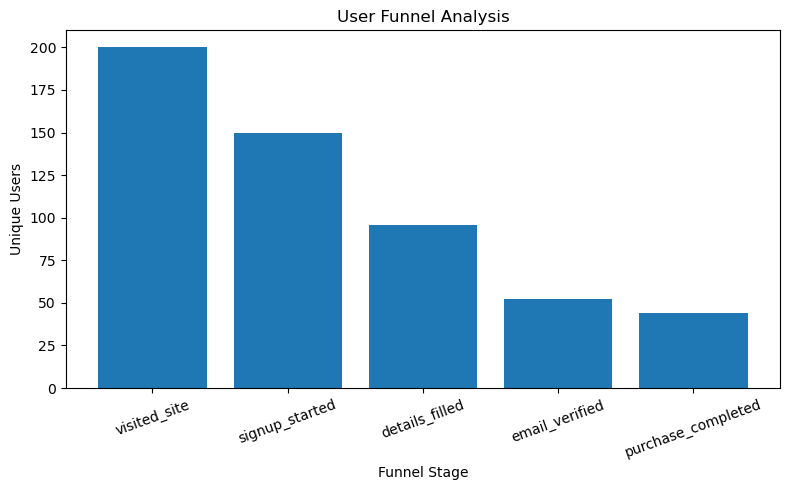

In [18]:
# Visualization
plt.figure(figsize=(8,5))
plt.bar(result.index, result["Unique Users"])
plt.title("User Funnel Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Recommendation
The biggest drop-off occurs at the stage with the highest user loss. This indicates friction in the user journey. Improving the UI, reducing unnecessary form fields, simplifying verification, or adding progress indicators can help improve conversions.